In [34]:
import numpy as np
import scipy as sp
import scienceplots
import matplotlib.pyplot as plt
from scipy.signal import sawtooth

plt.style.use(["science","no-latex"])

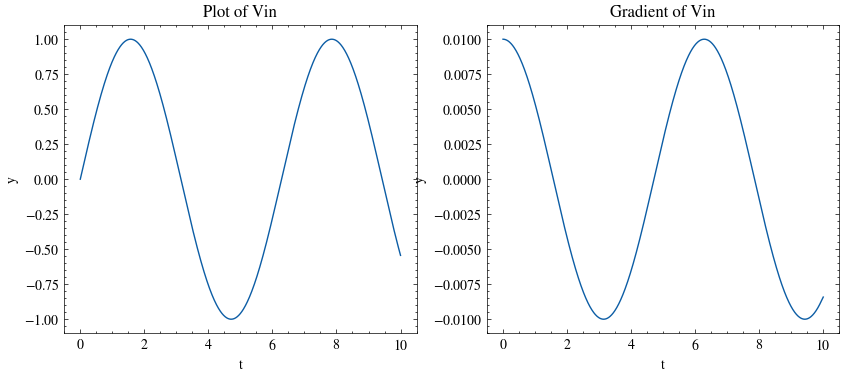

In [33]:
t=np.linspace(0,10,1000)
Vin=np.sin(t)
dVin=np.gradient(Vin)

fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(10,4))
ax[0].plot(t,Vin,label="Vin")
ax[0].set_title("Plot of Vin")
ax[1].plot(t,dVin,label="diff(Vin)")
ax[1].set_title("Gradient of Vin")

for ax in ax:
    ax.set_ylabel("y")
    ax.set_xlabel("t")
plt.show()

## Simulation for a Differentiator op amp

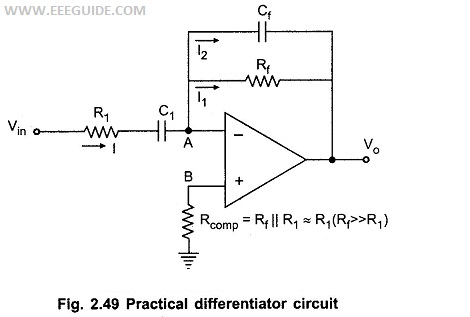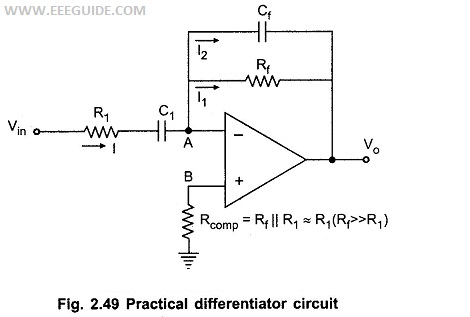


Differentiator

$V_o=-RC\frac{dV_i}{dt}$

In [72]:
def differentiator(input_signal="sine",
                   frequency=1000,
                   amplitude=5,
                   R=100e3,
                   C=100e-9,
                   duration=0.01,
                   fs=100000):
    """
    Simulates an ideal differentiator.

    Parameters
    ----------
    input_signal : str
        'sine', 'cos', 'square', 'triangle', or 'sawtooth'
    frequency : float
        Signal frequency in Hz
    amplitude : float
        Signal amplitude (Volts)
    R : float
        Resistance (Ohms)
    C : float
        Capacitance (Farads)
    duration : float
        Simulation time (seconds)
    fs : float
        Sampling frequency (Hz)
    """

    # Time vector
    t = np.arange(0, duration, 1/fs)

    # Generate input signal
    if input_signal.lower() == "sine":
        vin = amplitude * np.sin(2*np.pi*frequency*t)

    elif input_signal.lower() == "cos":
        vin = amplitude * np.cos(2*np.pi*frequency*t)

    elif input_signal.lower() == "square":
        vin = amplitude * sp.signal.square(2*np.pi*frequency*t)

    elif input_signal.lower() == "triangle":
        vin = amplitude * sp.signal.sawtooth(
            2*np.pi*frequency*t,
            width=0.5
        )

    elif input_signal.lower() == "sawtooth":
        vin = amplitude * sp.signal.sawtooth(
            2*np.pi*frequency*t
        )

    else:
        raise ValueError(
            "Choose one of: sine, cos, square, triangle, sawtooth"
        )

    # Differentiate with respect to time
    dvdt = np.gradient(vin, t)

    # Differentiator output
    vout = -R * C * dvdt

    # Plot
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))

    ax[0].plot(t, vin, linewidth=2)
    ax[0].set_title(f"Input Signal ({input_signal.capitalize()})")
    ax[0].set_ylabel("Voltage (V)")
    ax[0].grid(True)

    ax[1].plot(t, vout, color='red', linewidth=2)
    ax[1].set_title("Differentiator Output")
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Voltage (V)")
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

    #return t, vin, vout



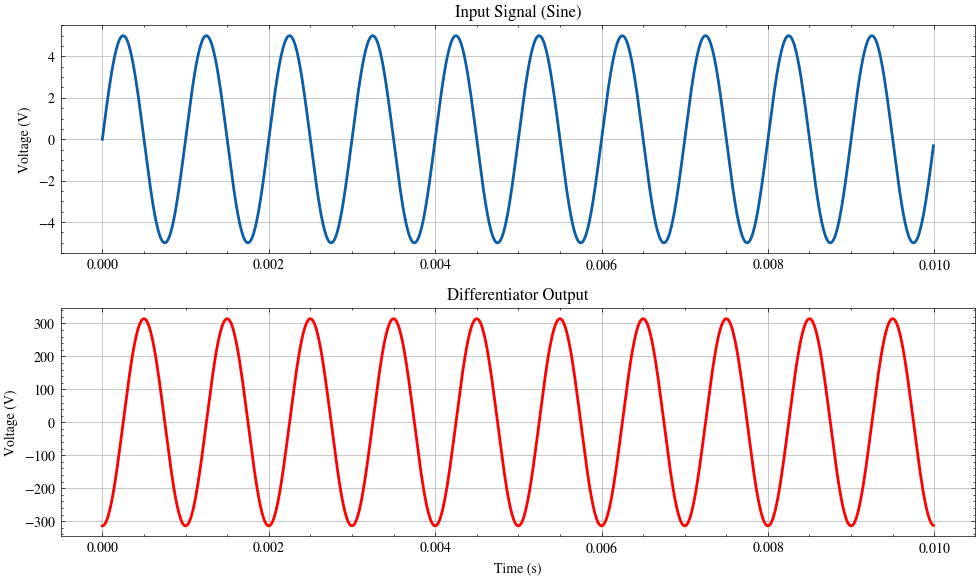

In [73]:
differentiator()

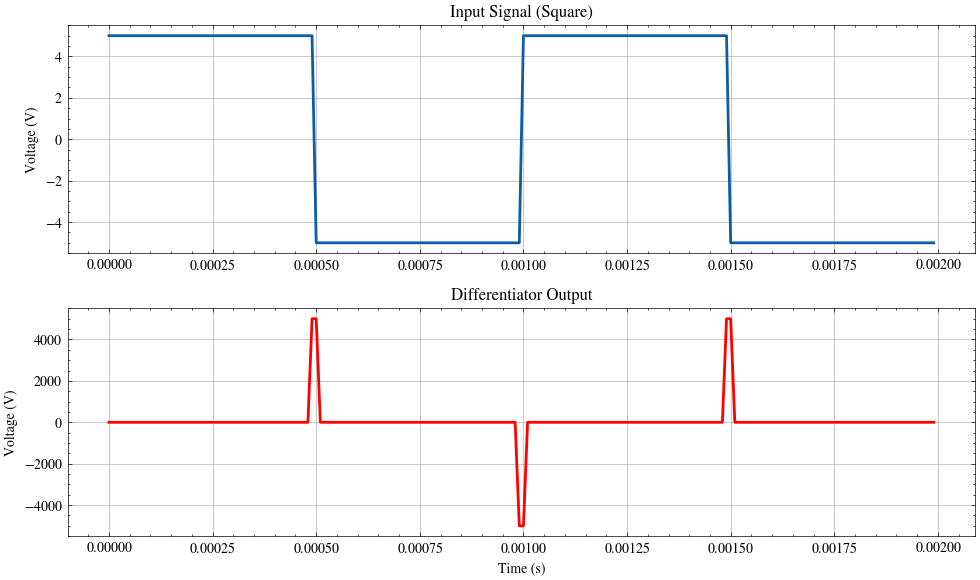

In [82]:
differentiator(input_signal="square",duration=0.002)

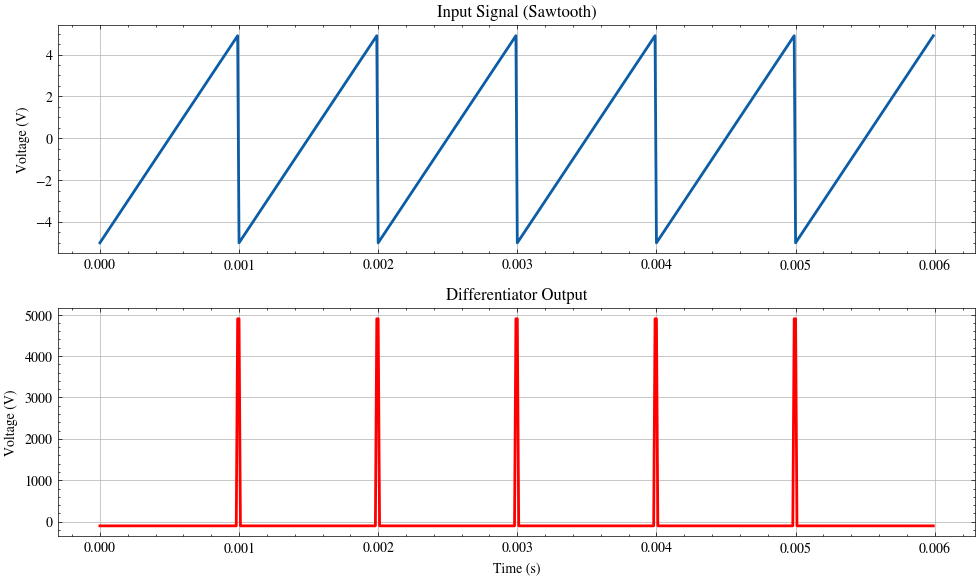

In [86]:
differentiator(input_signal="sawtooth",duration=0.006)